In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [21]:
df = pd.read_csv("manufacturing_maintenance_data.csv")

df.head()

,Machine_ID,Machine_Category,Maintenance_Date,Downtime_Hours,Production_Volume,Failure_Count
0,M001,CNC Machine,2025-03-29,8.28,921,1
1,M001,CNC Machine,2025-04-17,11.68,1134,1
2,M001,CNC Machine,2025-07-07,8.74,713,2
3,M001,CNC Machine,2025-11-10,3.96,1084,2
4,M001,CNC Machine,2025-11-16,13.33,957,2


In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 180
Number of columns: 6


In [4]:
print(df.columns.tolist())

['Machine_ID', 'Machine_Category', 'Maintenance_Date', 'Downtime_Hours', 'Production_Volume', 'Failure_Count']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Machine_ID         180 non-null    object 
 1   Machine_Category   180 non-null    object 
 2   Maintenance_Date   180 non-null    object 
 3   Downtime_Hours     180 non-null    float64
 4   Production_Volume  180 non-null    int64  
 5   Failure_Count      180 non-null    int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 8.6+ KB


In [6]:
df["Maintenance_Date"] = pd.to_datetime(df["Maintenance_Date"])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Machine_ID         180 non-null    object        
 1   Machine_Category   180 non-null    object        
 2   Maintenance_Date   180 non-null    datetime64[ns]
 3   Downtime_Hours     180 non-null    float64       
 4   Production_Volume  180 non-null    int64         
 5   Failure_Count      180 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 8.6+ KB


In [8]:
df.isnull().sum()

Machine_ID           0
Machine_Category     0
Maintenance_Date     0
Downtime_Hours       0
Production_Volume    0
Failure_Count        0
dtype: int64

In [9]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [10]:
print(
    "Negative downtime:",
    (df["Downtime_Hours"] < 0).sum()
)

print(
    "Negative production:",
    (df["Production_Volume"] < 0).sum()
)

print(
    "Negative failures:",
    (df["Failure_Count"] < 0).sum()
)

Negative downtime: 0
Negative production: 0
Negative failures: 0


In [11]:
df.describe()

,Maintenance_Date,Downtime_Hours,Production_Volume,Failure_Count
count,180,180.000000,180.000000,180.000000
mean,2025-07-10 04:40:00,12.873778,1040.133333,1.961111
min,2025-01-04 00:00:00,3.900000,441.000000,0.000000
25%,2025-04-14 00:00:00,10.217500,829.500000,1.000000
50%,2025-07-13 00:00:00,12.880000,1040.000000,2.000000
75%,2025-10-05 18:00:00,15.557500,1242.250000,3.000000
max,2025-12-31 00:00:00,21.590000,1521.000000,7.000000
std,NaN,3.927823,259.038001,1.387751


In [12]:
df["Machine_Category"].value_counts()

Machine_Category
CNC Machine        30
Conveyor           30
Press Machine      30
Lathe              30
Milling Machine    30
Robotic Arm        30
Name: count, dtype: int64

In [13]:
print(
    "Number of unique machines:",
    df["Machine_ID"].nunique()
)

Number of unique machines: 30


In [14]:
maintenance_frequency = df.groupby("Machine_ID").agg(
    Maintenance_Count=("Maintenance_Date", "count"),
    Average_Downtime=("Downtime_Hours", "mean"),
    Total_Downtime=("Downtime_Hours", "sum"),
    Total_Failures=("Failure_Count", "sum"),
    Average_Production=("Production_Volume", "mean")
).sort_values(
    "Maintenance_Count",
    ascending=False
)

maintenance_frequency.round(2)

,Maintenance_Count,Average_Downtime,Total_Downtime,Total_Failures,Average_Production
Machine_ID,,,,,
M001,6,9.22,55.31,9,974.00
M002,6,16.54,99.27,9,674.83
M003,6,18.21,109.26,18,1322.00
M004,6,11.50,68.99,11,1299.00
M005,6,9.32,55.92,11,1127.83
M006,6,7.62,45.71,17,1355.50
M007,6,9.44,56.63,18,1336.17
M008,6,13.15,78.89,7,1156.67
M009,6,14.12,84.74,8,1022.17


In [15]:
frequency_downtime_corr = (
    maintenance_frequency["Maintenance_Count"]
    .corr(maintenance_frequency["Average_Downtime"])
)

print(
    "Correlation between Maintenance Frequency and Average Downtime:",
    round(frequency_downtime_corr, 3)
)

Correlation between Maintenance Frequency and Average Downtime: nan


C:\Users\gobik\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\gobik\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [16]:
df = pd.read_csv("manufacturing_maintenance_data.csv")

df.head()

,Machine_ID,Machine_Category,Maintenance_Date,Downtime_Hours,Production_Volume,Failure_Count
0,M001,CNC Machine,2025-03-29,8.28,921,1
1,M001,CNC Machine,2025-04-17,11.68,1134,1
2,M001,CNC Machine,2025-07-07,8.74,713,2
3,M001,CNC Machine,2025-11-10,3.96,1084,2
4,M001,CNC Machine,2025-11-16,13.33,957,2


In [17]:
df["Maintenance_Date"] = pd.to_datetime(
    df["Maintenance_Date"]
)

In [18]:
maintenance_frequency = df.groupby("Machine_ID").agg(
    Maintenance_Count=("Maintenance_Date", "count"),
    Average_Downtime=("Downtime_Hours", "mean"),
    Total_Downtime=("Downtime_Hours", "sum"),
    Total_Failures=("Failure_Count", "sum"),
    Average_Production=("Production_Volume", "mean")
).sort_values(
    "Maintenance_Count",
    ascending=False
)

maintenance_frequency.round(2)

,Maintenance_Count,Average_Downtime,Total_Downtime,Total_Failures,Average_Production
Machine_ID,,,,,
M001,6,9.22,55.31,9,974.00
M002,6,16.54,99.27,9,674.83
M003,6,18.21,109.26,18,1322.00
M004,6,11.50,68.99,11,1299.00
M005,6,9.32,55.92,11,1127.83
M006,6,7.62,45.71,17,1355.50
M007,6,9.44,56.63,18,1336.17
M008,6,13.15,78.89,7,1156.67
M009,6,14.12,84.74,8,1022.17


In [19]:
frequency_downtime_corr = (
    maintenance_frequency["Maintenance_Count"]
    .corr(maintenance_frequency["Average_Downtime"])
)

print(
    "Correlation between Maintenance Frequency and Average Downtime:",
    round(frequency_downtime_corr, 3)
)

Correlation between Maintenance Frequency and Average Downtime: nan


C:\Users\gobik\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\gobik\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [20]:
maintenance_frequency.round(2)

,Maintenance_Count,Average_Downtime,Total_Downtime,Total_Failures,Average_Production
Machine_ID,,,,,
M001,6,9.22,55.31,9,974.00
M002,6,16.54,99.27,9,674.83
M003,6,18.21,109.26,18,1322.00
M004,6,11.50,68.99,11,1299.00
M005,6,9.32,55.92,11,1127.83
M006,6,7.62,45.71,17,1355.50
M007,6,9.44,56.63,18,1336.17
M008,6,13.15,78.89,7,1156.67
M009,6,14.12,84.74,8,1022.17


In [22]:
df["Maintenance_Date"] = pd.to_datetime(
    df["Maintenance_Date"]
)

In [23]:
maintenance_frequency = df.groupby("Machine_ID").agg(
    Maintenance_Count=("Maintenance_Date", "count"),
    Average_Downtime=("Downtime_Hours", "mean"),
    Total_Downtime=("Downtime_Hours", "sum"),
    Total_Failures=("Failure_Count", "sum"),
    Average_Production=("Production_Volume", "mean")
).sort_values(
    "Maintenance_Count",
    ascending=False
)

maintenance_frequency.round(2)

,Maintenance_Count,Average_Downtime,Total_Downtime,Total_Failures,Average_Production
Machine_ID,,,,,
M001,6,9.22,55.31,9,974.00
M002,6,16.54,99.27,9,674.83
M003,6,18.21,109.26,18,1322.00
M004,6,11.50,68.99,11,1299.00
M005,6,9.32,55.92,11,1127.83
M006,6,7.62,45.71,17,1355.50
M007,6,9.44,56.63,18,1336.17
M008,6,13.15,78.89,7,1156.67
M009,6,14.12,84.74,8,1022.17


In [24]:
frequency_downtime_corr = (
    maintenance_frequency["Maintenance_Count"]
    .corr(maintenance_frequency["Average_Downtime"])
)

print(
    "Correlation between Maintenance Frequency and Average Downtime:",
    round(frequency_downtime_corr, 3)
)

Correlation between Maintenance Frequency and Average Downtime: nan


C:\Users\gobik\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\gobik\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [25]:
df = pd.read_csv("manufacturing_maintenance_data.csv")

df["Maintenance_Date"] = pd.to_datetime(
    df["Maintenance_Date"]
)

print("Rows:", len(df))
print("Machines:", df["Machine_ID"].nunique())

Rows: 180
Machines: 30


In [26]:
maintenance_frequency = df.groupby("Machine_ID").agg(
    Maintenance_Count=("Maintenance_Date", "count"),
    Average_Downtime=("Downtime_Hours", "mean"),
    Total_Downtime=("Downtime_Hours", "sum"),
    Total_Failures=("Failure_Count", "sum"),
    Average_Production=("Production_Volume", "mean")
).sort_values(
    "Maintenance_Count",
    ascending=False
)

maintenance_frequency.round(2)

,Maintenance_Count,Average_Downtime,Total_Downtime,Total_Failures,Average_Production
Machine_ID,,,,,
M001,6,9.22,55.31,9,974.00
M002,6,16.54,99.27,9,674.83
M003,6,18.21,109.26,18,1322.00
M004,6,11.50,68.99,11,1299.00
M005,6,9.32,55.92,11,1127.83
M006,6,7.62,45.71,17,1355.50
M007,6,9.44,56.63,18,1336.17
M008,6,13.15,78.89,7,1156.67
M009,6,14.12,84.74,8,1022.17


In [27]:
frequency_downtime_corr = (
    maintenance_frequency["Maintenance_Count"]
    .corr(maintenance_frequency["Average_Downtime"])
)

print(
    "Correlation between Maintenance Frequency and Average Downtime:",
    round(frequency_downtime_corr, 3)
)

Correlation between Maintenance Frequency and Average Downtime: nan


C:\Users\gobik\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\gobik\AppData\Roaming\Python\Python311\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [28]:
df = df.sort_values(
    ["Machine_ID", "Maintenance_Date"]
).reset_index(drop=True)

df.head(10)

,Machine_ID,Machine_Category,Maintenance_Date,Downtime_Hours,Production_Volume,Failure_Count
0,M001,CNC Machine,2025-03-29,8.28,921,1
1,M001,CNC Machine,2025-04-17,11.68,1134,1
2,M001,CNC Machine,2025-07-07,8.74,713,2
3,M001,CNC Machine,2025-11-10,3.96,1084,2
4,M001,CNC Machine,2025-11-16,13.33,957,2
5,M001,CNC Machine,2025-12-10,9.32,1035,1
6,M002,Conveyor,2025-02-22,18.46,723,2
7,M002,Conveyor,2025-08-30,16.96,709,1
8,M002,Conveyor,2025-09-09,17.02,677,1
9,M002,Conveyor,2025-09-21,19.36,566,2


In [29]:
df["Previous_Downtime"] = df.groupby(
    "Machine_ID"
)["Downtime_Hours"].shift(1)

In [30]:
df["Downtime_Change"] = (
    df["Downtime_Hours"]
    - df["Previous_Downtime"]
)

In [31]:
df["Downtime_Change_Percentage"] = (
    df["Downtime_Change"]
    / df["Previous_Downtime"]
) * 100

In [32]:
before_after = df.dropna(
    subset=["Previous_Downtime"]
).copy()

In [33]:
before_after[
    [
        "Machine_ID",
        "Maintenance_Date",
        "Previous_Downtime",
        "Downtime_Hours",
        "Downtime_Change",
        "Downtime_Change_Percentage"
    ]
].head(15)

,Machine_ID,Maintenance_Date,Previous_Downtime,Downtime_Hours,Downtime_Change,Downtime_Change_Percentage
1,M001,2025-04-17,8.28,11.68,3.40,41.062802
2,M001,2025-07-07,11.68,8.74,-2.94,-25.171233
3,M001,2025-11-10,8.74,3.96,-4.78,-54.691076
4,M001,2025-11-16,3.96,13.33,9.37,236.616162
5,M001,2025-12-10,13.33,9.32,-4.01,-30.082521
7,M002,2025-08-30,18.46,16.96,-1.50,-8.125677
8,M002,2025-09-09,16.96,17.02,0.06,0.353774
9,M002,2025-09-21,17.02,19.36,2.34,13.748531
10,M002,2025-10-28,19.36,15.61,-3.75,-19.369835
11,M002,2025-11-06,15.61,11.86,-3.75,-24.023062


In [34]:
improved_events = (
    before_after["Downtime_Change"] < 0
).sum()

increased_events = (
    before_after["Downtime_Change"] > 0
).sum()

same_events = (
    before_after["Downtime_Change"] == 0
).sum()

total_comparisons = len(before_after)

print("Total before-after comparisons:", total_comparisons)
print("Downtime decreased:", improved_events)
print("Downtime increased:", increased_events)
print("Downtime unchanged:", same_events)

Total before-after comparisons: 150
Downtime decreased: 74
Downtime increased: 76
Downtime unchanged: 0


In [35]:
improvement_rate = (
    improved_events / total_comparisons
) * 100

print(
    "Percentage of events followed by lower downtime:",
    round(improvement_rate, 2),
    "%"
)

Percentage of events followed by lower downtime: 49.33 %


In [36]:
average_before = before_after[
    "Previous_Downtime"
].mean()

average_after = before_after[
    "Downtime_Hours"
].mean()

print(
    "Average downtime before maintenance:",
    round(average_before, 2)
)

print(
    "Average downtime after maintenance:",
    round(average_after, 2)
)

print(
    "Average change in downtime:",
    round(average_after - average_before, 2)
)

Average downtime before maintenance: 12.88
Average downtime after maintenance: 12.89
Average change in downtime: 0.0


In [37]:
category_maintenance = before_after.groupby(
    "Machine_Category"
).agg(
    Average_Before_Downtime=(
        "Previous_Downtime",
        "mean"
    ),
    Average_After_Downtime=(
        "Downtime_Hours",
        "mean"
    ),
    Average_Downtime_Change=(
        "Downtime_Change",
        "mean"
    ),
    Total_Failures=(
        "Failure_Count",
        "sum"
    ),
    Maintenance_Events=(
        "Machine_ID",
        "count"
    )
).round(2)

category_maintenance

,Average_Before_Downtime,Average_After_Downtime,Average_Downtime_Change,Total_Failures,Maintenance_Events
Machine_Category,,,,,
CNC Machine,11.44,11.62,0.18,51,25
Conveyor,14.32,14.15,-0.17,45,25
Lathe,14.22,14.44,0.22,56,25
Milling Machine,11.27,10.70,-0.57,48,25
Press Machine,14.98,15.52,0.54,43,25
Robotic Arm,11.06,10.88,-0.18,55,25


In [38]:
category_maintenance.sort_values(
    "Average_Downtime_Change"
)

,Average_Before_Downtime,Average_After_Downtime,Average_Downtime_Change,Total_Failures,Maintenance_Events
Machine_Category,,,,,
Milling Machine,11.27,10.70,-0.57,48,25
Robotic Arm,11.06,10.88,-0.18,55,25
Conveyor,14.32,14.15,-0.17,45,25
CNC Machine,11.44,11.62,0.18,51,25
Lathe,14.22,14.44,0.22,56,25
Press Machine,14.98,15.52,0.54,43,25


In [39]:
maintenance_threshold = maintenance_frequency[
    "Maintenance_Count"
].quantile(0.75)

downtime_threshold = maintenance_frequency[
    "Average_Downtime"
].quantile(0.75)

print(
    "High maintenance threshold:",
    maintenance_threshold
)

print(
    "High downtime threshold:",
    round(downtime_threshold, 2)
)

High maintenance threshold: 6.0
High downtime threshold: 14.87


In [40]:
excessive_maintenance = maintenance_frequency[
    (maintenance_frequency["Maintenance_Count"]
     >= maintenance_threshold)
    &
    (maintenance_frequency["Average_Downtime"]
     >= downtime_threshold)
]

excessive_maintenance.round(2)

,Maintenance_Count,Average_Downtime,Total_Downtime,Total_Failures,Average_Production
Machine_ID,,,,,
M002,6,16.54,99.27,9,674.83
M003,6,18.21,109.26,18,1322.00
M016,6,17.06,102.35,10,1095.00
M018,6,14.92,89.53,15,1345.33
M020,6,17.39,104.31,10,1377.83
M021,6,17.23,103.37,7,913.17
M022,6,16.87,101.22,11,1183.00
M027,6,14.88,89.31,14,1151.83


In [41]:
attention_machines = maintenance_frequency.sort_values(
    ["Average_Downtime", "Total_Failures"],
    ascending=False
)

attention_machines.head(10).round(2)

,Maintenance_Count,Average_Downtime,Total_Downtime,Total_Failures,Average_Production
Machine_ID,,,,,
M003,6,18.21,109.26,18,1322.00
M020,6,17.39,104.31,10,1377.83
M021,6,17.23,103.37,7,913.17
M016,6,17.06,102.35,10,1095.00
M022,6,16.87,101.22,11,1183.00
M002,6,16.54,99.27,9,674.83
M018,6,14.92,89.53,15,1345.33
M027,6,14.88,89.31,14,1151.83
M019,6,14.82,88.89,12,775.67


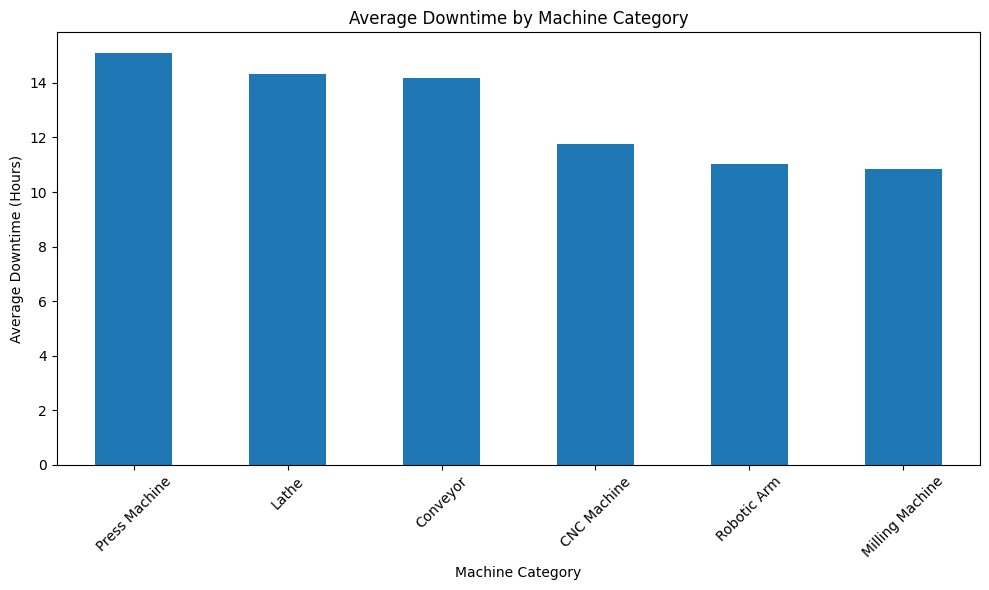

In [42]:
category_downtime = df.groupby(
    "Machine_Category"
)["Downtime_Hours"].mean().sort_values(
    ascending=False
)

plt.figure(figsize=(10, 6))

category_downtime.plot(kind="bar")

plt.title("Average Downtime by Machine Category")
plt.xlabel("Machine Category")
plt.ylabel("Average Downtime (Hours)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

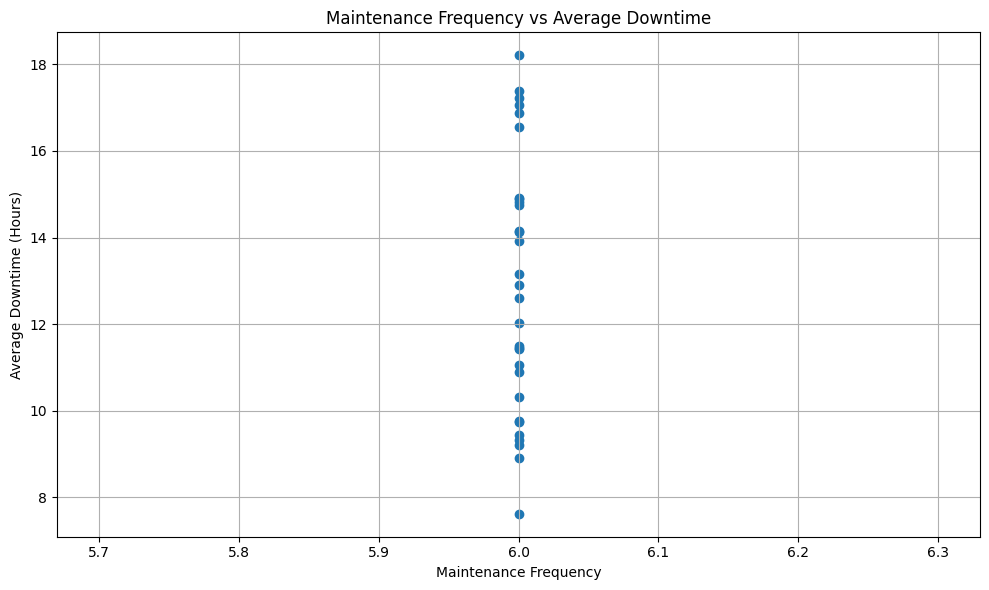

In [43]:
plt.figure(figsize=(10, 6))

plt.scatter(
    maintenance_frequency["Maintenance_Count"],
    maintenance_frequency["Average_Downtime"]
)

plt.xlabel("Maintenance Frequency")
plt.ylabel("Average Downtime (Hours)")
plt.title("Maintenance Frequency vs Average Downtime")

plt.grid(True)
plt.tight_layout()
plt.show()

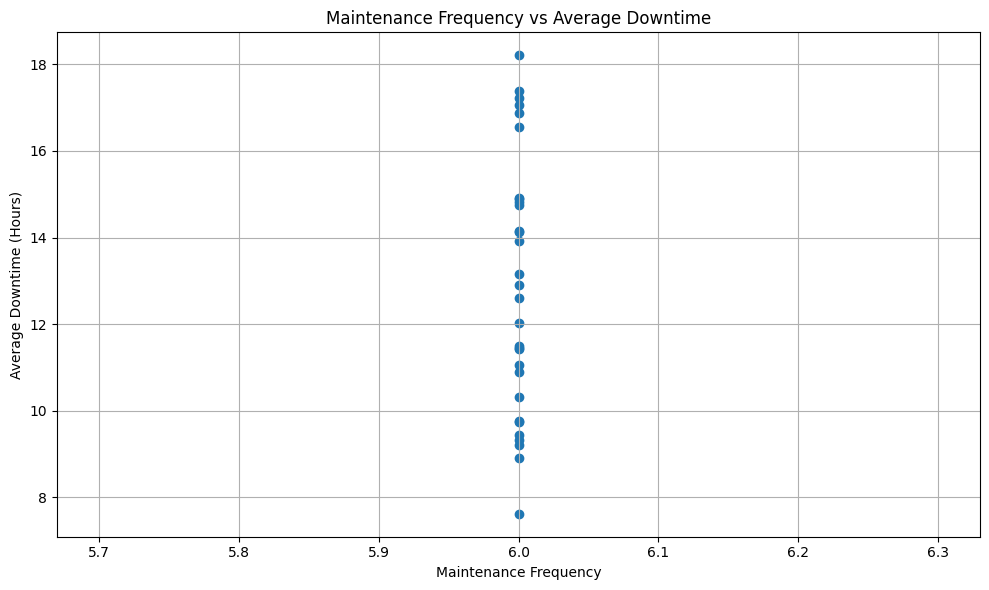

In [44]:
plt.figure(figsize=(10, 6))

plt.scatter(
    maintenance_frequency["Maintenance_Count"],
    maintenance_frequency["Average_Downtime"]
)

plt.xlabel("Maintenance Frequency")
plt.ylabel("Average Downtime (Hours)")
plt.title("Maintenance Frequency vs Average Downtime")

plt.grid(True)
plt.tight_layout()
plt.show()

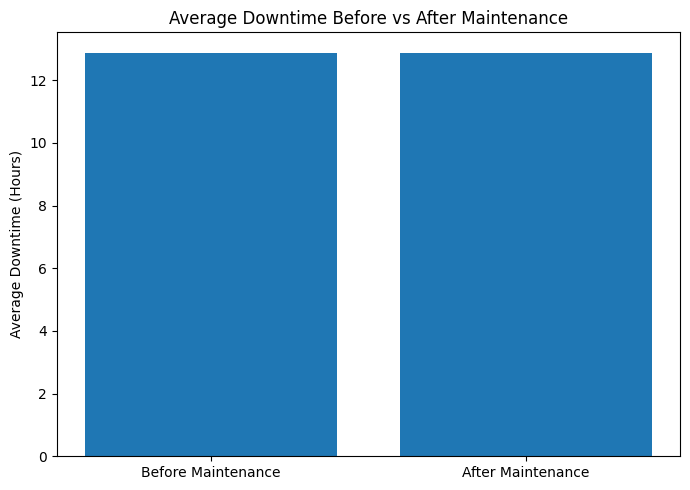

In [45]:
plt.figure(figsize=(7, 5))

plt.bar(
    ["Before Maintenance", "After Maintenance"],
    [average_before, average_after]
)

plt.ylabel("Average Downtime (Hours)")
plt.title("Average Downtime Before vs After Maintenance")

plt.tight_layout()
plt.show()

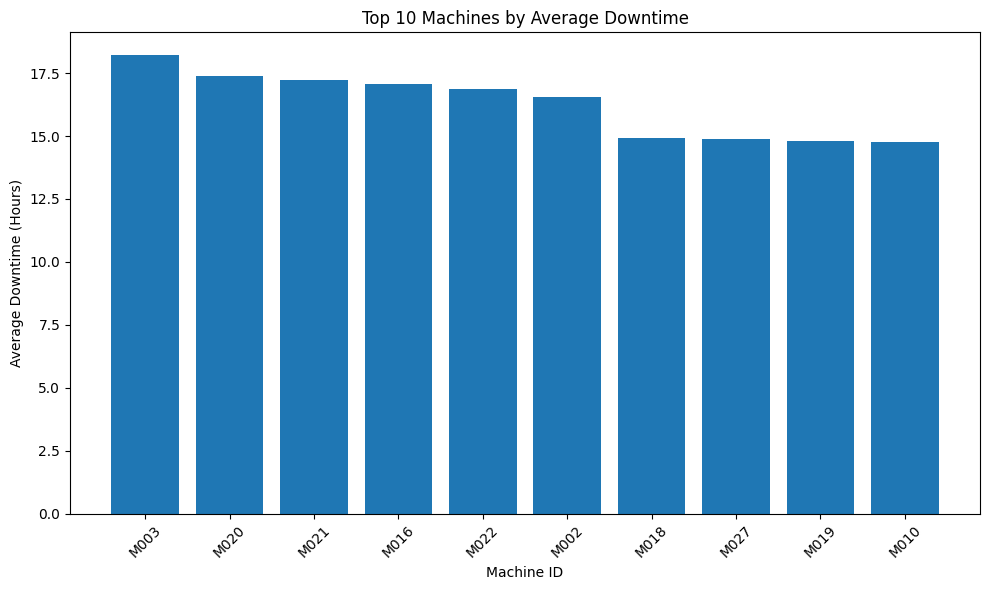

In [46]:
top_downtime = maintenance_frequency.sort_values(
    "Average_Downtime",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_downtime.index,
    top_downtime["Average_Downtime"]
)

plt.xlabel("Machine ID")
plt.ylabel("Average Downtime (Hours)")
plt.title("Top 10 Machines by Average Downtime")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [47]:
df["High_Downtime"] = (
    df["Downtime_Hours"] >= df["Downtime_Hours"].median()
).astype(int)

In [48]:
print(df["High_Downtime"].value_counts())

High_Downtime
0    90
1    90
Name: count, dtype: int64


In [49]:
print(df["High_Downtime"].value_counts())

High_Downtime
0    90
1    90
Name: count, dtype: int64


In [50]:
machine_frequency = df.groupby(
    "Machine_ID"
)["Maintenance_Date"].transform("count")

df["Maintenance_Frequency"] = machine_frequency

In [51]:
X = df[
    [
        "Maintenance_Frequency",
        "Production_Volume",
        "Failure_Count"
    ]
]

y = df["High_Downtime"]

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 144
Testing records: 36


In [53]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [54]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
[1 0 0 0 1 0 1 0 0 0 0 0 1 1 1 1 0 1 1 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0 0 0]


In [55]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("Accuracy:", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("F1 Score:", round(f1, 3))

Accuracy: 0.389
Precision: 0.333
Recall: 0.222
F1 Score: 0.267


In [56]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[10  8]
 [14  4]]


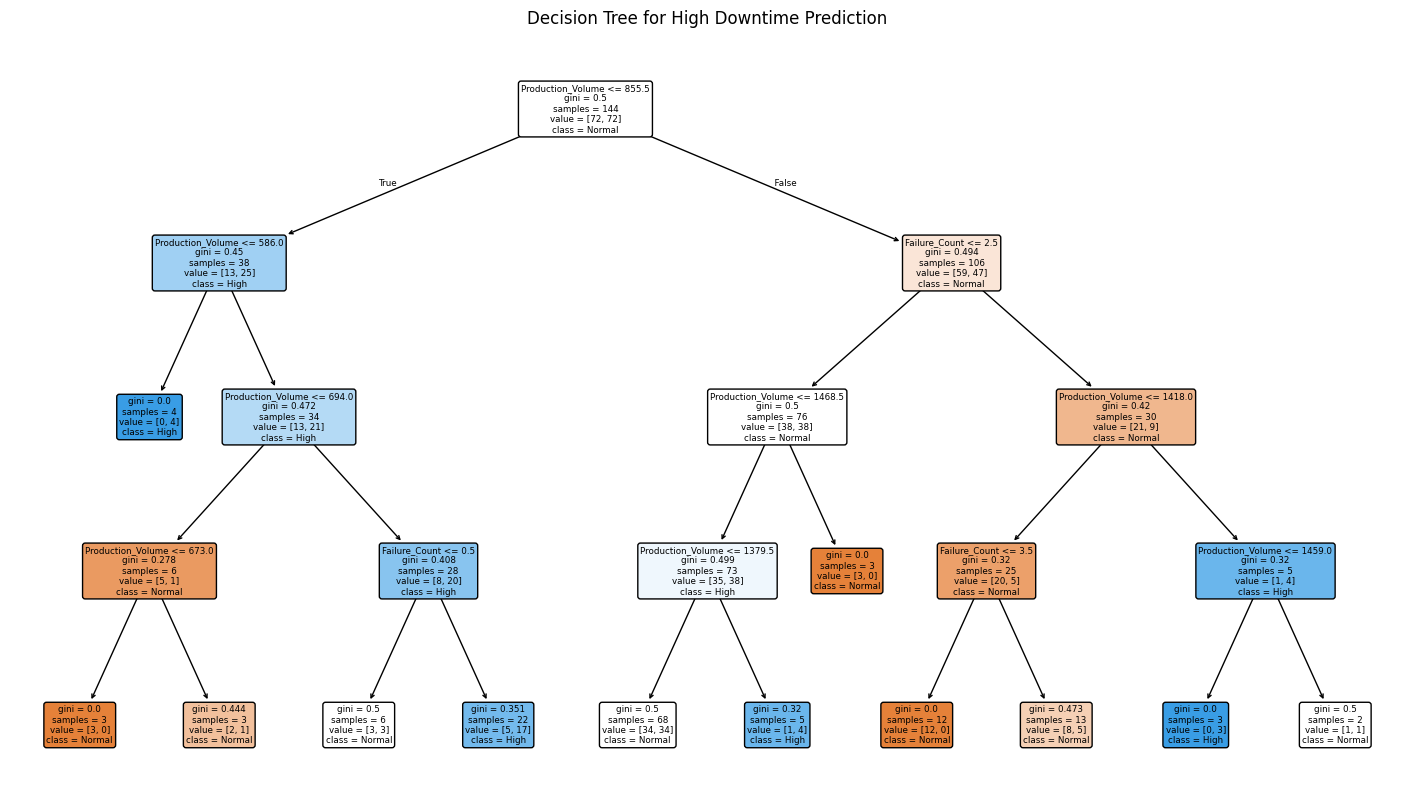

In [57]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Normal", "High"],
    filled=True,
    rounded=True
)

plt.title("Decision Tree for High Downtime Prediction")
plt.show()

In [58]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
1,Production_Volume,0.75164
2,Failure_Count,0.24836
0,Maintenance_Frequency,0.00000


In [59]:
# FINAL PROJECT SUMMARY

print("==============================================")
print("MANUFACTURING MAINTENANCE ANALYSIS SUMMARY")
print("==============================================")

# Basic dataset information
print("\n1. DATASET")
print("Total maintenance records:", len(df))
print("Total machines:", df["Machine_ID"].nunique())
print("Machine categories:", df["Machine_Category"].nunique())

# Downtime
print("\n2. DOWNTIME")
print(
    "Overall average downtime:",
    round(df["Downtime_Hours"].mean(), 2),
    "hours"
)

print(
    "Maximum downtime:",
    round(df["Downtime_Hours"].max(), 2),
    "hours"
)

# Before vs After
print("\n3. BEFORE VS AFTER MAINTENANCE")
print(
    "Average downtime before:",
    round(average_before, 2),
    "hours"
)

print(
    "Average downtime after:",
    round(average_after, 2),
    "hours"
)

print(
    "Average change:",
    round(average_after - average_before, 2),
    "hours"
)

print(
    "Events followed by lower downtime:",
    improved_events,
    "(",
    round(improvement_rate, 2),
    "%)"
)

# Maintenance frequency
print("\n4. MAINTENANCE FREQUENCY")

print(
    "Average maintenance events per machine:",
    round(
        maintenance_frequency["Maintenance_Count"].mean(),
        2
    )
)

print(
    "Correlation between maintenance frequency and average downtime:",
    round(frequency_downtime_corr, 3)
)

# Category
highest_category = category_maintenance[
    "Average_After_Downtime"
].idxmax()

lowest_category = category_maintenance[
    "Average_After_Downtime"
].idxmin()

print("\n5. MACHINE CATEGORY")

print(
    "Highest average downtime category:",
    highest_category
)

print(
    "Lowest average downtime category:",
    lowest_category
)

# Machine attention
highest_downtime_machine = maintenance_frequency[
    "Average_Downtime"
].idxmax()

print("\n6. MACHINE ATTENTION")

print(
    "Machine with highest average downtime:",
    highest_downtime_machine
)

print(
    "Average downtime:",
    round(
        maintenance_frequency.loc[
            highest_downtime_machine,
            "Average_Downtime"
        ],
        2
    ),
    "hours"
)

# Decision Tree
print("\n7. DECISION TREE")

print("Accuracy:", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("F1 Score:", round(f1, 3))

print("\n==============================================")
print("ANALYSIS COMPLETED")
print("==============================================")

MANUFACTURING MAINTENANCE ANALYSIS SUMMARY

1. DATASET
Total maintenance records: 180
Total machines: 30
Machine categories: 6

2. DOWNTIME
Overall average downtime: 12.87 hours
Maximum downtime: 21.59 hours

3. BEFORE VS AFTER MAINTENANCE
Average downtime before: 12.88 hours
Average downtime after: 12.89 hours
Average change: 0.0 hours
Events followed by lower downtime: 74 ( 49.33 %)

4. MAINTENANCE FREQUENCY
Average maintenance events per machine: 6.0
Correlation between maintenance frequency and average downtime: nan

5. MACHINE CATEGORY
Highest average downtime category: Press Machine
Lowest average downtime category: Milling Machine

6. MACHINE ATTENTION
Machine with highest average downtime: M003
Average downtime: 18.21 hours

7. DECISION TREE
Accuracy: 0.389
Precision: 0.333
Recall: 0.222
F1 Score: 0.267

ANALYSIS COMPLETED


In [60]:
print("KEY INSIGHTS")
print("=" * 50)

print(
    f"1. The dataset contains {df['Machine_ID'].nunique()} machines "
    f"across {df['Machine_Category'].nunique()} machine categories."
)

print(
    f"2. The overall average downtime is "
    f"{df['Downtime_Hours'].mean():.2f} hours."
)

print(
    f"3. Average downtime changed from "
    f"{average_before:.2f} hours before maintenance "
    f"to {average_after:.2f} hours after maintenance."
)

print(
    f"4. {improvement_rate:.2f}% of maintenance comparisons "
    f"were followed by lower downtime."
)

print(
    f"5. The correlation between maintenance frequency and "
    f"average downtime is {frequency_downtime_corr:.3f}."
)

print(
    f"6. {highest_category} has the highest average downtime "
    f"among the machine categories."
)

print(
    f"7. {highest_downtime_machine} has the highest average "
    f"downtime and should be examined for possible maintenance "
    f"or operational issues."
)

KEY INSIGHTS
1. The dataset contains 30 machines across 6 machine categories.
2. The overall average downtime is 12.87 hours.
3. Average downtime changed from 12.88 hours before maintenance to 12.89 hours after maintenance.
4. 49.33% of maintenance comparisons were followed by lower downtime.
5. The correlation between maintenance frequency and average downtime is nan.
6. Press Machine has the highest average downtime among the machine categories.
7. M003 has the highest average downtime and should be examined for possible maintenance or operational issues.


# Practical Action Plan

1. Monitor machines with consistently high downtime and failure counts.
2. Review maintenance schedules for machines receiving frequent maintenance but still showing high downtime.
3. Compare maintenance effectiveness across different machine categories.
4. Investigate repeated failures even when maintenance frequency is high.
5. Use downtime and failure trends to prioritize maintenance activities.
6. Review production losses associated with high-downtime machines.
7. Use the Decision Tree model as a supporting tool to identify factors associated with high downtime.
8. Continue collecting maintenance and downtime records so that future analysis can evaluate long-term maintenance effectiveness.

# Conclusion

The analysis evaluated the relationship between preventive maintenance and machine downtime using machine-level maintenance, downtime, production and failure data.

The analysis compared downtime across maintenance events, examined different machine categories, evaluated maintenance frequency, and identified machines with high downtime and failure levels.

The results provide a data-based view of maintenance performance and help identify machines that require further investigation. The Decision Tree model was also developed to classify machines/events according to high or normal downtime.

Overall, the analysis can support maintenance teams in prioritizing machines, reviewing maintenance schedules and improving downtime monitoring.

In [61]:
df.to_csv(
    "manufacturing_maintenance_analysis_final.csv",
    index=False
)

print("Final analyzed dataset saved successfully.")

Final analyzed dataset saved successfully.
